# 04 — Validation and limitations of the Germany 2018 analysis

**Question.** Are the 2018 Germany results physically plausible, and what is out of scope?

This notebook validates the area-weighted resource proxy against Bundesnetzagentur SMARD
generation data. It distinguishes structural agreement (timing and variability) from level bias,
then demonstrates a simple, explicitly non-operational bias correction. Its area-weighting
limitation is addressed—but not fully solved—by the OPSD capacity-weighted fleet proxy in
notebook 05. No data is downloaded during notebook execution.

## 1. What is being validated?

**Capacity factor (CF)** normalizes energy by installed capacity and elapsed time:

$$CF = \frac{E}{P_{installed}\,\Delta t}.$$

For example, 1,200 MWh generated by a 200 MW fleet in one day gives
$1,200/(200\times24)=0.25$. This permits technologies and fleets of different size to be
compared on a common 0–1 scale.

The COSMO-REA6 series is an **area-weighted resource proxy** produced from weather fields and
simplified conversion curves. SMARD reports actual electricity fed into the German grid.
They are related but not identical quantities. Validation therefore asks two questions:

1. Does the proxy reproduce the timing and co-variability of high and low generation (correlation)?
2. Does it reproduce the level and error magnitude (mean bias, MAE, and RMSE)?

A discrepancy is not necessarily a reanalysis error: installed-capacity geography, turbine
design, losses, curtailment, and the use of year-end capacity in the observed denominator all
contribute.

## 2. Load data

In [1]:
%matplotlib inline
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
ASSETS = ROOT / "app_assets" / "2018"

with open(ASSETS / "cosmo_rea6_dach_2018_metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)

daily_all = pd.read_parquet(ASSETS / "cosmo_rea6_dach_2018_daily_country_timeseries.parquet")
g = daily_all[daily_all["country"] == "de"].copy().sort_values("time").reset_index(drop=True)

print(f"Germany records: {len(g)}")

Germany records: 365


## 3. Internal consistency checks

- Exactly 365 days in 2018 (not a leap year).
- All capacity factors in [0, 1].
- No missing Germany values.

In [2]:
n_days = g.shape[0]
cf_min = g[["wind_cf", "solar_cf", "combined_cf"]].min().min()
cf_max = g[["wind_cf", "solar_cf", "combined_cf"]].max().max()
missing = g[["wind_cf", "solar_cf", "combined_cf"]].isna().sum().sum()

internal = pd.Series({
    "days": n_days,
    "capacity factor range": f"[{cf_min:.4f}, {cf_max:.4f}]",
    "missing values": missing,
    "status": "PASS" if n_days == 365 and cf_min >= -0.01 and cf_max <= 1.01 and missing == 0 else "FAIL",
}, name="internal check")
internal

days                                  365
capacity factor range    [0.0005, 0.8168]
missing values                          0
status                               PASS
Name: internal check, dtype: object

## 3. Plausibility against literature and observations

The table compares our 2018 Germany area-weighted proxies with independent reference ranges.
Differences are expected because the proxy is area-weighted, does not include losses/wake,
and uses daily means.

In [3]:
de = metrics["countries"]["de"]
plausibility = pd.DataFrame([
    {
        "metric": "Annual wind CF",
        "our value": f"{de['mean_wind_cf']:.3f}",
        "reference": "SMARD-derived 2018 fleet CF calculated below",
        "verdict": "requires quantitative comparison",
    },
    {
        "metric": "Annual solar CF",
        "our value": f"{de['mean_solar_cf']:.3f}",
        "reference": "SMARD-derived 2018 fleet CF calculated below",
        "verdict": "requires quantitative comparison",
    },
    {
        "metric": "Wind–solar correlation",
        "our value": f"{de['wind_solar_correlation']:.3f}",
        "reference": "Negative expected for seasonal cycle",
        "verdict": "physically consistent",
    },
    {
        "metric": "Max Dunkelflaute duration",
        "our value": f"{metrics['dunkelflaute_events']['by_country']['de']['max_duration']} days",
        "reference": "Published values depend strongly on definition and data period",
        "verdict": "Germany result; test threshold and bias sensitivity",
    },
    {
        "metric": "100-m wind",
        "our value": f"{de['mean_wspd100_m_s']:.2f} m/s",
        "reference": "German onshore ~5–6 m/s at 100 m",
        "verdict": "low, expected for area-weighted incl. weak-wind regions",
    },
])
plausibility

,metric,our value,reference,verdict
0,Annual wind CF,0.155,SMARD-derived 2018 fleet CF calculated below,requires quantitative comparison
1,Annual solar CF,0.128,SMARD-derived 2018 fleet CF calculated below,requires quantitative comparison
2,Wind–solar correlation,-0.373,Negative expected for seasonal cycle,physically consistent
3,Max Dunkelflaute duration,10 days,Published values depend strongly on definition...,Germany result; test threshold and bias sensit...
4,100-m wind,3.96 m/s,German onshore ~5–6 m/s at 100 m,"low, expected for area-weighted incl. weak-win..."


## 4. External reference: SMARD actual generation

**SMARD** is the Bundesnetzagentur (Germany's federal network regulator) national
electricity-market data portal. It publishes transparent market and power-system records.
The compact CSV used here was obtained from its day-resolution API with
`scripts/smard_download.py`; this notebook makes no download. Filters **4067** (onshore wind) and **4068** (photovoltaic) select German
generation. Attribution/licensing is **Bundesnetzagentur SMARD, CC BY 4.0**.

The file has `date`, daily onshore-wind and PV generation in MWh, the capacity denominators in
MW, and the resulting `wind_onshore_cf` and `solar_cf`. Daily MWh is divided by 24 h and by
published end-of-2018 capacity: 52,565 MW onshore wind and 45,277 MW PV. Thus the aggregation
is national and daily. There are **365 national daily records per technology**, not grid cells,
plant records, or plant locations.

Using year-end capacity slightly understates observed CF because capacity increased during
2018—especially PV. The comparison is therefore an informative first validation, not a final
fleet reconstruction. Wind is compared with **onshore wind only**, matching the land-based
COSMO proxy.

In [4]:
ref = pd.read_csv(ASSETS / "smard_de_2018_daily.csv", parse_dates=["date"])
model = g[["time", "wind_cf", "solar_cf"]].rename(columns={"time": "date"})
model["date"] = pd.to_datetime(model["date"]).dt.tz_localize(None).dt.normalize()
ref["date"] = pd.to_datetime(ref["date"]).dt.tz_localize(None).dt.normalize()
comparison = model.merge(ref[["date", "wind_onshore_cf", "solar_cf"]], on="date", suffixes=("_model", "_observed"))

coverage = pd.Series({
    "model days": len(model),
    "SMARD rows": len(ref),
    "SMARD unique dates": ref["date"].nunique(),
    "SMARD date minimum": ref["date"].min(),
    "SMARD date maximum": ref["date"].max(),
    "duplicate SMARD dates": int(ref["date"].duplicated().sum()),
    "matched days": len(comparison),
    "missing comparison values": int(comparison.isna().sum().sum()),
}, name="coverage")
coverage

model days                                   365
SMARD rows                                   365
SMARD unique dates                           365
SMARD date minimum           2018-01-01 00:00:00
SMARD date maximum           2018-12-31 00:00:00
duplicate SMARD dates                          0
matched days                                 365
missing comparison values                      0
Name: coverage, dtype: object

## 5. Daily validation metrics

- **Correlation ($r$)** measures timing and co-variability. It is insensitive to a constant
  multiplicative bias; high $r$ means high and low days tend to occur together.
- **Bias** is mean(model − observed). Positive values indicate overestimation.
- **MAE** is the mean absolute daily error and retains the intuitive CF scale.
- **RMSE** penalizes occasional large errors more strongly than MAE.

A model can therefore correlate well but remain biased. Both dimensions must be reported.

In [5]:
def validation_metrics(observed, modelled):
    error = modelled - observed
    return {
        "observed mean CF": observed.mean(),
        "model mean CF": modelled.mean(),
        "correlation": observed.corr(modelled),
        "bias": error.mean(),
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt(np.mean(error**2)),
    }

validation = pd.DataFrame({
    "wind": validation_metrics(comparison["wind_onshore_cf"], comparison["wind_cf"]),
    "solar": validation_metrics(comparison["solar_cf_observed"], comparison["solar_cf_model"]),
}).T.round(3)
validation

,observed mean CF,model mean CF,correlation,bias,MAE,RMSE
wind,0.194,0.155,0.945,-0.039,0.053,0.064
solar,0.104,0.128,0.980,0.024,0.026,0.034


**How to read the 2018 result.** Correlations above 0.9 indicate that the weather-derived
proxies capture the day-to-day ordering of German generation unusually well for such a simple
conversion model. Absolute levels tell a different story: area-weighted wind is low relative
to the installed fleet, while simplified PV is high relative to the SMARD series normalized
by year-end capacity. This combination is physically understandable—German wind capacity is
concentrated in windier regions, while PV conversion and the capacity denominator introduce
different biases—but it confirms that raw proxy CF should not be presented as actual output.

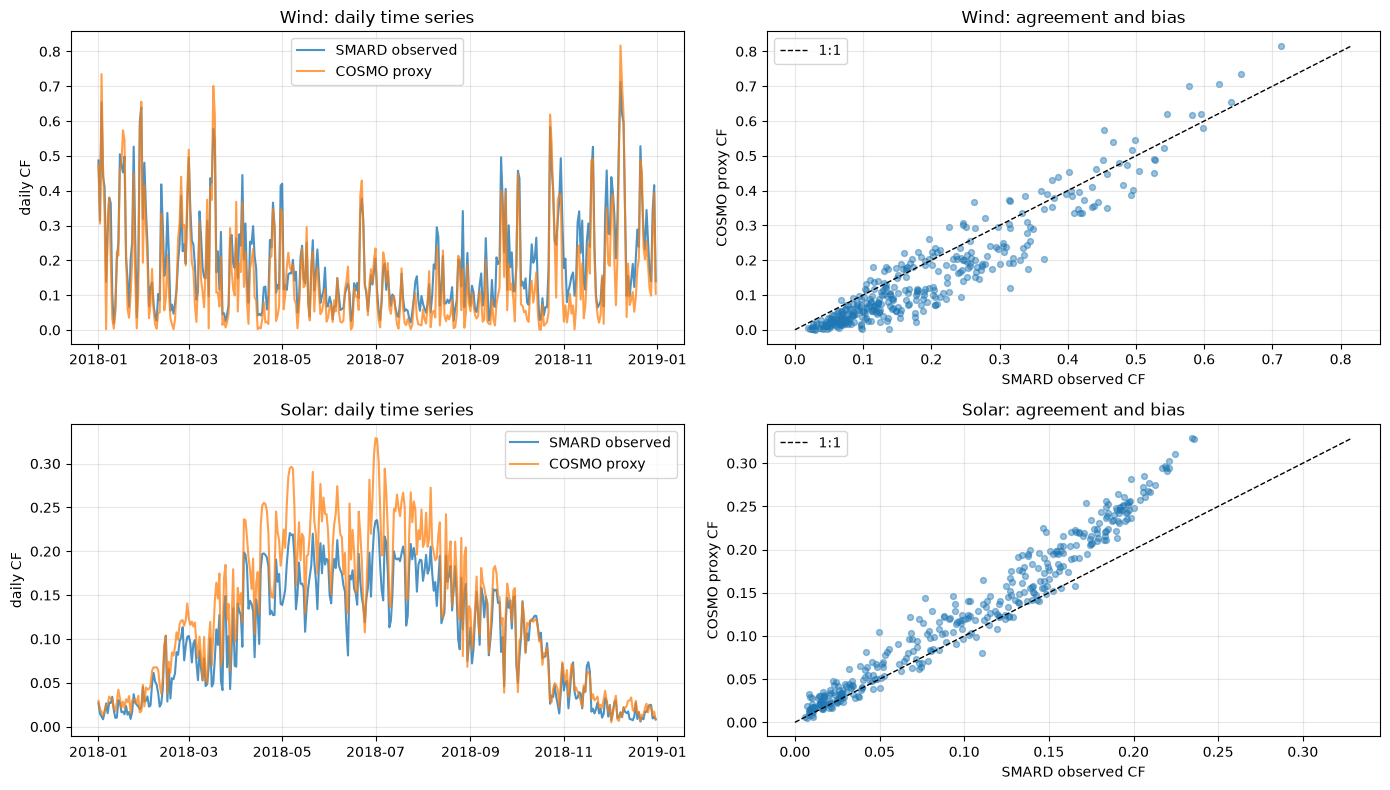

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
pairs = [
    ("wind_onshore_cf", "wind_cf", "Wind"),
    ("solar_cf_observed", "solar_cf_model", "Solar"),
]
for row, (obs, mod, title) in enumerate(pairs):
    axes[row, 0].plot(comparison["date"], comparison[obs], label="SMARD observed", alpha=0.8)
    axes[row, 0].plot(comparison["date"], comparison[mod], label="COSMO proxy", alpha=0.75)
    axes[row, 0].set_ylabel("daily CF")
    axes[row, 0].set_title(f"{title}: daily time series")
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].scatter(comparison[obs], comparison[mod], alpha=0.45, s=18)
    limit = max(comparison[obs].max(), comparison[mod].max())
    axes[row, 1].plot([0, limit], [0, limit], "k--", linewidth=1, label="1:1")
    axes[row, 1].set_xlabel("SMARD observed CF")
    axes[row, 1].set_ylabel("COSMO proxy CF")
    axes[row, 1].set_title(f"{title}: agreement and bias")
    axes[row, 1].legend()
    axes[row, 1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**How to read the daily panels.** In each left panel, peaks and troughs at the same dates mean
the proxy gets timing right; a persistent vertical gap means amplitude bias. Wind varies
through the year, while solar also has a strong seasonal envelope, so compare like seasons.
In each right panel, every dot is one national day. Dots on the dashed 1:1 line agree exactly;
dots above it are overestimated and dots below it are underestimated. A narrow diagonal cloud
indicates good timing, but an offset cloud can still have high correlation. Outliers are single
days and should not be assigned to one cause without operational and weather investigation.

## 6. Monthly error structure

Monthly aggregation suppresses day-to-day noise and reveals seasonal bias. Persistent monthly
differences point toward conversion or spatial-weighting limitations; isolated daily errors
may instead reflect weather timing or operational effects.

In [7]:
comparison["month"] = comparison["date"].dt.month
monthly = comparison.groupby("month").agg(
    wind_observed=("wind_onshore_cf", "mean"),
    wind_model=("wind_cf", "mean"),
    solar_observed=("solar_cf_observed", "mean"),
    solar_model=("solar_cf_model", "mean"),
)
monthly["wind_bias"] = monthly["wind_model"] - monthly["wind_observed"]
monthly["solar_bias"] = monthly["solar_model"] - monthly["solar_observed"]
monthly.round(3)

,wind_observed,wind_model,solar_observed,solar_model,wind_bias,solar_bias
month,,,,,,
1,0.321,0.289,0.021,0.027,-0.032,0.005
2,0.181,0.157,0.060,0.079,-0.025,0.019
3,0.230,0.193,0.082,0.111,-0.037,0.030
4,0.193,0.137,0.149,0.187,-0.056,0.038
5,0.152,0.128,0.176,0.231,-0.024,0.055
6,0.122,0.116,0.163,0.204,-0.006,0.040
7,0.093,0.072,0.183,0.234,-0.021,0.052
8,0.127,0.081,0.153,0.181,-0.046,0.028
9,0.162,0.107,0.125,0.137,-0.055,0.012


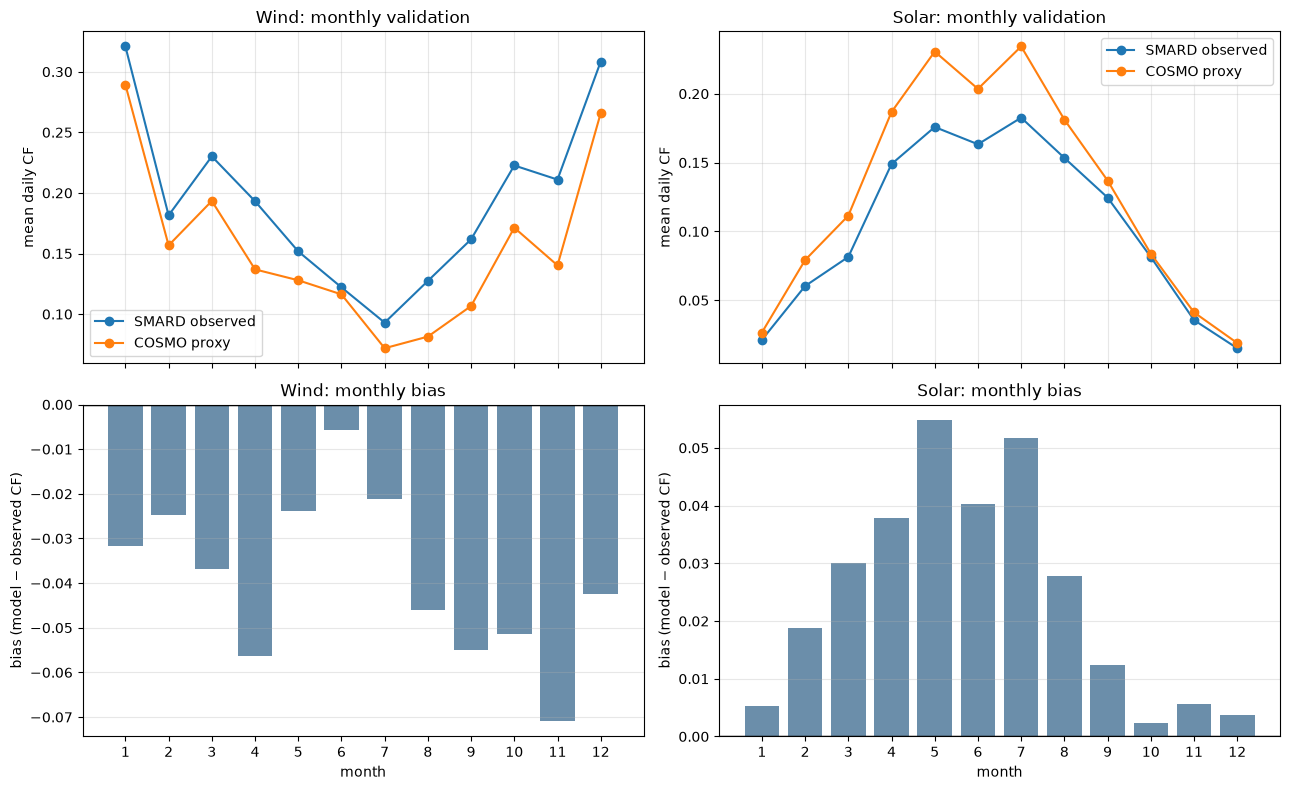

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for column, tech in enumerate(["wind", "solar"]):
    axes[0, column].plot(monthly.index, monthly[f"{tech}_observed"], "o-", label="SMARD observed")
    axes[0, column].plot(monthly.index, monthly[f"{tech}_model"], "o-", label="COSMO proxy")
    axes[0, column].set_ylabel("mean daily CF")
    axes[0, column].set_title(f"{tech.title()}: monthly validation")
    axes[0, column].grid(alpha=0.3)
    axes[0, column].legend()
    axes[1, column].bar(monthly.index, monthly[f"{tech}_bias"], color="#6b8eaa")
    axes[1, column].axhline(0, color="black", linewidth=1)
    axes[1, column].set_xticks(range(1, 13))
    axes[1, column].set_xlabel("month")
    axes[1, column].set_ylabel("bias (model − observed CF)")
    axes[1, column].set_title(f"{tech.title()}: monthly bias")
    axes[1, column].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**How to read monthly error.** A positive bar means the proxy is too high; a negative bar means
it is too low. The upper panels show whether seasonal timing agrees, while the bars expose
amplitude error. The same sign across many months suggests a persistent denominator,
conversion-curve, or spatial-weighting issue. A sign that changes by season suggests a
season-dependent limitation. One isolated month may reflect unusual weather timing or
operations. These are plausible categories, not proof of a particular cause.

## 7. Mean-ratio correction: a diagnostic experiment

We scale each proxy by observed mean CF divided by model mean CF, clipping to [0, 1]. This
removes annual level bias but does **not** repair timing, power-curve shape, or spatial
weighting. Because the correction is fitted and evaluated on the same year, it is an
**diagnostic sensitivity experiment—same-year calibration/evaluation; not independent validation**.

The corrected 50/50 hybrid CF gives equal weight to onshore-wind and PV rated capacities:
$CF_{hybrid}=0.5CF_{wind}+0.5CF_{solar}$. It is not Germany's historical capacity mix and
should not be interpreted as actual national combined generation.

In [9]:
wind_scale = comparison["wind_onshore_cf"].mean() / comparison["wind_cf"].mean()
solar_scale = comparison["solar_cf_observed"].mean() / comparison["solar_cf_model"].mean()
comparison["wind_cf_corrected"] = (comparison["wind_cf"] * wind_scale).clip(0, 1)
comparison["solar_cf_corrected"] = (comparison["solar_cf_model"] * solar_scale).clip(0, 1)
comparison["hybrid_cf_raw"] = 0.5 * comparison["wind_cf"] + 0.5 * comparison["solar_cf_model"]
comparison["hybrid_cf_corrected"] = 0.5 * comparison["wind_cf_corrected"] + 0.5 * comparison["solar_cf_corrected"]

correction_summary = pd.Series({
    "wind scale factor": wind_scale,
    "solar scale factor": solar_scale,
    "raw hybrid mean": comparison["hybrid_cf_raw"].mean(),
    "corrected hybrid mean": comparison["hybrid_cf_corrected"].mean(),
}).round(3)
correction_summary

wind scale factor        1.250
solar scale factor       0.811
raw hybrid mean          0.142
corrected hybrid mean    0.149
dtype: float64

## 8. Consequence for Dunkelflaute detection

Here an event is a consecutive run of at least two days with 50/50 hybrid CF below 0.10.
Comparing raw and corrected proxies shows how sensitive the catalogue is to systematic level
bias. This threshold is a screening definition; it is not equivalent to unmet demand because
load, storage, imports, transmission, and dispatchable generation are absent.

In [10]:
def event_table(dates, values, threshold=0.10, min_duration=2):
    low = pd.Series(values < threshold).reset_index(drop=True)
    dates = pd.Series(pd.to_datetime(dates)).reset_index(drop=True)
    groups = low.ne(low.shift()).cumsum()
    records = []
    for _, idx in low[low].groupby(groups[low]).groups.items():
        idx = list(idx)
        if len(idx) >= min_duration:
            segment = values.iloc[idx]
            records.append({
                "start": dates.iloc[idx[0]].date(),
                "end": dates.iloc[idx[-1]].date(),
                "duration_days": len(idx),
                "mean_cf": segment.mean(),
                "severity": (threshold - segment).clip(lower=0).sum(),
            })
    return pd.DataFrame(records)

raw_events = event_table(comparison["date"], comparison["hybrid_cf_raw"])
corrected_events = event_table(comparison["date"], comparison["hybrid_cf_corrected"])
event_comparison = pd.DataFrame({
    "raw proxy": [len(raw_events), raw_events["duration_days"].max(), raw_events["severity"].sum()],
    "mean-corrected proxy": [len(corrected_events), corrected_events["duration_days"].max(), corrected_events["severity"].sum()],
}, index=["event count", "longest event (days)", "total severity (CF-days)"])
event_comparison.round(3)

,raw proxy,mean-corrected proxy
event count,22.000,27.000
longest event (days),10.000,9.000
total severity (CF-days),3.052,3.273


In [11]:
corrected_events.sort_values("duration_days", ascending=False).head(10)

,start,end,duration_days,mean_cf,severity
22,2018-11-01,2018-11-09,9,0.053642,0.417222
21,2018-10-15,2018-10-22,8,0.053262,0.373906
9,2018-03-23,2018-03-27,5,0.071886,0.140570
6,2018-02-16,2018-02-20,5,0.055228,0.223859
25,2018-12-14,2018-12-18,5,0.062038,0.189808
4,2018-02-06,2018-02-10,5,0.047990,0.260052
16,2018-09-03,2018-09-06,4,0.082977,0.068092
24,2018-11-22,2018-11-25,4,0.041701,0.233197
20,2018-10-06,2018-10-09,4,0.069734,0.121066
0,2018-01-10,2018-01-12,3,0.027474,0.217578


**2018 interpretation.** Mean correction does not automatically reduce event frequency. In
this case it raises wind CF but lowers solar CF because the raw proxy underestimates observed
wind and overestimates observed PV. More autumn/winter days cross the 10% hybrid threshold,
so event count can increase even while the longest event shortens. This is precisely why a
Dunkelflaute catalogue must not be "fixed" by assuming that removal of mean bias will move
every risk statistic in the same direction. Distribution shape, season, technology mix, and
threshold all matter.

## 9. Limitations and scope

These are not bugs; they are the boundary of what this prototype can claim. They should be
stated explicitly in any presentation.

| Limitation | Consequence |
|---|---|
| Daily means in the annual workflow | Notebook 06 supplies a one-month hourly resolution and SMARD validation case study, but not full-year or multi-year hourly coverage. |
| 10 m → 100 m power law (α = 0.143) | Valid for flat, neutral conditions; unreliable in complex terrain and stable nocturnal layers. |
| Generic wind power curve | No site-specific turbine, wake, availability, or icing losses. |
| Simplified solar model | No tilt, azimuth, soiling, snow, or inverter clipping. |
| Area weighting in this notebook | Notebook 05 subsequently adds OPSD capacity weighting, but incomplete coordinates, static weights, and generic conversion curves remain. |
| One year (2018) | No interannual variability, no return periods, no trend. |
| COSMO-REA6 period | Ends in August 2019; cannot assess future climate change. |
| Absolute threshold 10% | Transparent but arbitrary; a real risk study would test a range of thresholds. |

## 10. Conclusion

Internal checks establish that the pipeline is complete and numerically consistent; the SMARD
comparison determines whether the resource proxies reproduce actual German fleet behaviour.
Correlation should be interpreted as temporal skill, while bias and MAE quantify errors in
level and magnitude. Any reduction in low-output events after mean correction demonstrates
threshold sensitivity rather than proving that the corrected catalogue is climatologically
accurate.

The appropriate scientific label remains **validated methods prototype**: stronger than a
plausibility-only exercise, but not a production forecast, adequacy assessment, or bankable
resource study. Notebook 05 supplies capacity-weighted aggregation and shows that it improves
wind mean bias but not every daily metric. Time-varying installed capacity, improved conversion,
and independent-year evaluation remain outside this study. Notebook 06 validates one November at
hourly resolution; it does not provide full-year or multi-year hourly coverage.